<a href="https://colab.research.google.com/github/Priyadarshini-yadav13/Rashmi/blob/main/ANN_churn_management.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

we have that churn management data set and we need to do data analysis using ANN

In [ ]:
##importing important libraries
import pandas as pd ## for data manupolation and dataframe
import numpy as np ##for numerical calculations
import matplotlib.pyplot as plt ## for Data visualisation
import seaborn as sns ## for advance data visualisation
import warnings
warnings.filterwarnings('ignore') ## for ignoring the warnings


In [ ]:
## Loading the data
df=pd.read_csv("/content/Churn_Modelling.csv")

In [ ]:
display(df.head())

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## DATA description
it is the dataset of a U.S. bank customer for getting the information that , this particular customer will leave bank or not.
RowNumber
CustomerId
Surname
CreditScore- credit score of the customer
Geography- Geography of the customer.
Gender-Gender of the customer.
Age-age of the customer
Tenure-the time period of a customer in the bank
Balance-average balance of the customer
NumOfProducts-number of the product of the bank the customer has
HasCrCard
IsActiveMember-customer is an active member or not?
EstimatedSalary-the estimated salary of the customer
Exit-will he sustain in the bank or will exit the bank?

In [ ]:
df.head(5)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
df.shape

(10000, 14)

In [ ]:
df.shape[0]

10000

In [ ]:
df.shape[1]

14

In [ ]:
df.size

140000

In [ ]:
## removing the column row number, customer ID, and surname
df = df.drop(columns=["RowNumber", "CustomerId", "Surname"])

In [ ]:
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [ ]:
## Findout wheither EXITED is balanced or not


In [ ]:
display(df['Exited'].value_counts())

,count
Exited,
0,7963
1,2037


Since the data is imbalanced but since we are using ANN, so for now we can ignore it.

In [ ]:
## checking the missed value data
df.isnull().sum()

,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0
HasCrCard,0
IsActiveMember,0
EstimatedSalary,0


There is no null value in the data.

In [ ]:
## Checking the Duplicate values
df.duplicated().sum()

np.int64(0)

In [ ]:
## There is no duplicate value in the data.

In [ ]:
numerical_features = df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = df.select_dtypes(include=['object']).columns

print("Numerical Features:", numerical_features.tolist())
print("Categorical Features:", categorical_features.tolist())

Numerical Features: ['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Categorical Features: ['Geography', 'Gender']


In [ ]:
## Seperate out Numerical/Int Variables.
numerical_features = [feature for feature in df.columns if df[feature].dtypes != 'O' ]
print(len(numerical_features))
df[numerical_features].head()

9


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,42,2,0.00,1,1,1,101348.88,1
1,608,41,1,83807.86,1,0,1,112542.58,0
2,502,42,8,159660.80,3,1,0,113931.57,1
3,699,39,1,0.00,2,0,0,93826.63,0
4,850,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
## Seperate out categorical Variables.
categorical_features = [feature for feature in df.columns if df[feature].dtypes == 'O' ]
print(len(categorical_features))
df[categorical_features].head()

2


,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female


In [ ]:
## Numerical variables are usually of 2 type
## 1. Continous variable and Discrete Variables

discrete_feature = [feature for feature in numerical_features if len(df[feature].unique())<25]
print(len(discrete_feature))
discrete_feature

5


['Tenure', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'Exited']

In [ ]:
# Continous Features


continous_feature = [feature for feature in numerical_features if feature not in discrete_feature]
print("Continuous feature Count {}".format(len(continous_feature)))
df[continous_feature].head()

Continuous feature Count 4


,CreditScore,Age,Balance,EstimatedSalary
0,619,42,0.00,101348.88
1,608,41,83807.86,112542.58
2,502,42,159660.80,113931.57
3,699,39,0.00,93826.63
4,850,43,125510.82,79084.10


In [ ]:
## Unique value in discrete column
def print_unique_col_values(df):
    i=1
    for column in df:
        str = "{i}. {a} column have {b} unique values"
        print(str.format(i=i,a=column,b=df[column].unique()))
        i=i+1

In [ ]:
print_unique_col_values(df[discrete_feature])

1. Tenure column have [ 2  1  8  7  4  6  3 10  5  9  0] unique values
2. NumOfProducts column have [1 3 2 4] unique values
3. HasCrCard column have [1 0] unique values
4. IsActiveMember column have [1 0] unique values
5. Exited column have [1 0] unique values


In [ ]:
df[categorical_features].head()

,Geography,Gender
0,France,Female
1,Spain,Female
2,France,Female
3,France,Female
4,Spain,Female


In [ ]:
for feature in categorical_features:
    print(f"{feature} column have {df[feature].unique()} unique values")

Geography column have ['France' 'Spain' 'Germany'] unique values
Gender column have ['Female' 'Male'] unique values


In [ ]:
#Male->1, Female 0
df['Gender'].replace({'Female':1,'Male':0},inplace=True)

In [ ]:
#Lets apply One hot encoding for categorical column Geography

df_onehot = pd.get_dummies(data=df, columns=['Geography'],dtype=int)
df_onehot.columns

Index(['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts',
       'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited',
       'Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [ ]:
df_onehot.head(5)

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.538,1,0.324324,2,0.000000,1,1,1,0.506735,1,1,0,0
1,0.516,1,0.310811,1,0.334031,1,0,1,0.562709,0,0,0,1
2,0.304,1,0.324324,8,0.636357,3,1,0,0.569654,1,1,0,0
3,0.698,1,0.283784,1,0.000000,2,0,0,0.469120,0,1,0,0
4,1.000,1,0.337838,2,0.500246,1,1,1,0.395400,0,0,0,1


In [ ]:
## Data Scaling -->>Continous data only
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_onehot[continous_feature] = scaler.fit_transform(df_onehot[continous_feature])

In [ ]:
df_onehot.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,0.538,1,0.324324,2,0.000000,1,1,1,0.506735,1,1,0,0
1,0.516,1,0.310811,1,0.334031,1,0,1,0.562709,0,0,0,1
2,0.304,1,0.324324,8,0.636357,3,1,0,0.569654,1,1,0,0
3,0.698,1,0.283784,1,0.000000,2,0,0,0.469120,0,1,0,0
4,1.000,1,0.337838,2,0.500246,1,1,1,0.395400,0,0,0,1


In [ ]:
## Seprating the input and output variables
X = df_onehot.drop(columns=['Exited'])
y = df_onehot['Exited']

In [ ]:
## split the data in train and test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((8000, 12), (2000, 12), (8000,), (2000,))

In [ ]:
##building and compiling the ANN model
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, ReLU
from tensorflow.keras.optimizers import Adam

In [ ]:
model = Sequential()
model.add(Dense(units=256, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(units=128, activation='relu'))
model.add(Dense(units=64, activation='relu'))
model.add(Dense(units=1, activation='sigmoid'))

In [ ]:
##compile the ANN model
model.compile(optimizer=Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])

In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 256)            │         3,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,545 (174.00 KB)

 Trainable params: 44,545 (174.00 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history=model.fit(X_train,y_train,epochs=100,validation_split=.2)

Epoch 1/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7977 - loss: 0.4875 - val_accuracy: 0.8112 - val_loss: 0.4381
Epoch 2/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8097 - loss: 0.4436 - val_accuracy: 0.8319 - val_loss: 0.4070
Epoch 3/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8239 - loss: 0.4038 - val_accuracy: 0.8369 - val_loss: 0.3774
Epoch 4/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8363 - loss: 0.3803 - val_accuracy: 0.8388 - val_loss: 0.3657
Epoch 5/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8444 - loss: 0.3691 - val_accuracy: 0.8494 - val_loss: 0.3667
Epoch 6/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8498 - loss: 0.3594 - val_accuracy: 0.8431 - val_loss: 0.3572
Epoch 7/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8525 - loss: 0.3526 - val_accuracy: 0.8487 - val_loss: 0.3615
Epoch 8/100
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8548 - loss: 0.3514 - val_accu

## we got 88% accuracy.

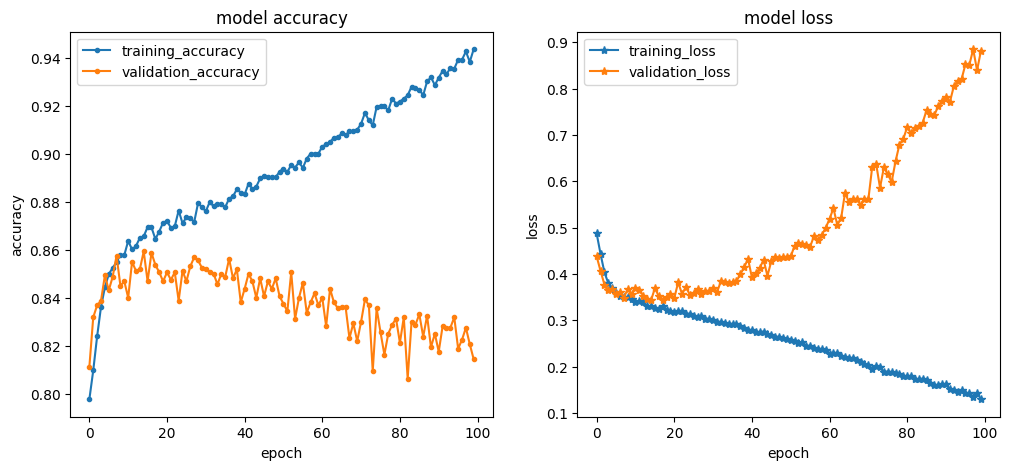

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,5))

plt.subplot(1,2,1) #one row two column and the first subplot
plt.plot(history.history['accuracy'],label='training_accuracy',marker=".")
plt.plot(history.history['val_accuracy'],label='validation_accuracy',marker=".")
plt.title('model accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()

plt.subplot(1,2,2) #one row two column and the second subplot
plt.plot(history.history['loss'],label='training_loss',marker="*")
plt.plot(history.history['val_loss'],label='validation_loss',marker="*")
plt.title('model loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()

plt.show()

In [ ]:
## Testing the model
prediction=model.predict(X_test)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


In [ ]:
prediction

array([[6.9566167e-12],
       [1.2025296e-07],
       [2.5426210e-03],
       ...,
       [2.2568204e-01],
       [9.0781605e-04],
       [5.4756498e-01]], dtype=float32)

In [89]:
y_pred=np.where(prediction>0.5,1,0)

In [90]:
y_pred[:]

array([[0],
       [0],
       [0],
       ...,
       [0],
       [0],
       [1]])

In [92]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.8285

In [ ]:
y_pred = []
for element in prediction:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [ ]:
y_pred[:10]

[0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.88      0.92      0.90      1607
           1       0.58      0.47      0.52       393

    accuracy                           0.83      2000
   macro avg       0.73      0.69      0.71      2000
weighted avg       0.82      0.83      0.82      2000



Text(95.72222222222221, 0.5, 'Truth')

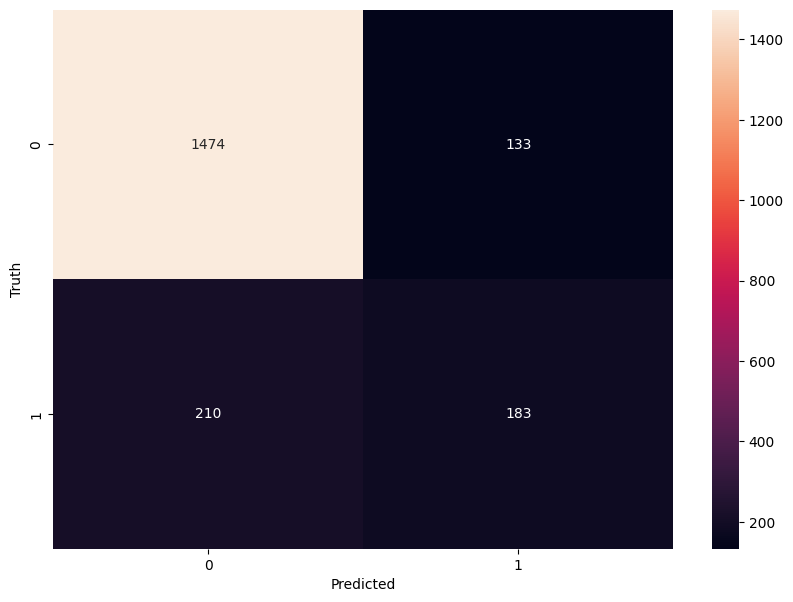

In [87]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')